# Perceptron

---

![](https://upload.wikimedia.org/wikipedia/en/5/52/Mark_I_perceptron.jpeg)

*Mark I Perceptron machine, the first implementation of the perceptron algorithm*

This notebook implements the binary Perceptron in Python and compares it with the predefined `sklearn.linear_model.Perceptron`

---

## What is a Perceptron?

The Perceptron is one of the oldest and simplest supervised learning algorithms. It was invented by Frank Rosenblatt in 1957. You can think of it as a single artificial neuron that learns to classify data into two classes.

Given a data point $\mathbf{x} = (x_1, x_2, \ldots, x_d)$, the perceptron computes a weighted sum and produces a binary prediction:

$$z = \mathbf{w} \cdot \mathbf{x} + b = w_1 x_1 + w_2 x_2 + \ldots + w_d x_d + b$$

$$\hat{y} = \text{sign}(z) = \begin{cases} +1 & \text{if } z \geq 0 \\ -1 & \text{if } z < 0 \end{cases}$$

Where:
- $\mathbf{w}$ = weight vector (one weight per feature)
- $b$ = bias term (shifts the decision boundary)
- $\hat{y} \in \{-1, +1\}$ = predicted class label

---

## The Learning Rule

The perceptron updates its weights only when it makes a mistake. The update rule is:

$$\mathbf{w} \leftarrow \mathbf{w} + y_i \cdot \mathbf{x}_i$$
$$b \leftarrow b + y_i$$

Where $y_i$ is the true label of the misclassified point.

If we predicted $-1$ but the true label is $+1$, we push the weights in the direction of $\mathbf{x}_i$. If we predicted $+1$ but the true label is $-1$, we push them in the opposite direction.

---

### Imports

In [322]:
# Install required libraries
%pip install numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [323]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.metrics import accuracy_score

# This makes the random results repeatable every time we run the notebook
np.random.seed(42)

### Generate Dataset

We create a simple 2D dataset with two classes

In [324]:
"""
Create 2-class dataset
X contains input points, y_raw the class labels 0 or 1
"""
X, y_raw = make_blobs(
    n_samples=100,              # total points
    centers=[(-2, -2), (2, 2)], # center coords of 2 groups
    cluster_std=0.9,            # control spread of groups
    random_state=42             # fixed random state -> data always the same
)

y = np.where(y_raw == 0, -1, 1) # convert labels from {0, 1} to {-1, 1}

Visualization of the dataset

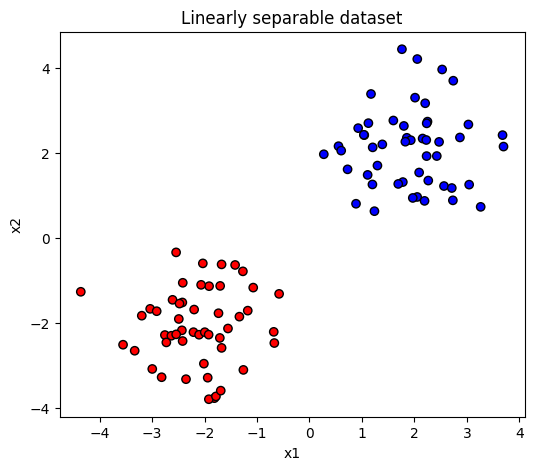

In [325]:
colors = ['red' if label == -1 else 'blue' for label in y]  # red = class -1; blue = class 1

plt.figure(figsize=(6, 5))                                  # create figure with width = 6 inches & height = 5 in
plt.scatter(X[:, 0], X[:, 1], c=colors, edgecolor='k')      # draw points on scatter plot; 1 arg = x coords of points, 2nd = y coords
plt.title('Linearly separable dataset')
plt.xlabel('x1')            
plt.ylabel('x2')
plt.show()

### Define Perceptron Class

In [326]:
class Perceptron:
    
    def __init__(self, n_features, max_iter=100):
        self.weights = np.zeros(n_features)         # 1 weight per input feature, all set to 0
        self.bias = 0.0                             # start bias at 0.0
        self.max_iter = max_iter                    # max. number of iterations
        self.history = []                           # track errors per epoch


    def _decision_function(self, X):                # compute linear score Xw + b 
        return X @ self.weights + self.bias         # @ symbol means matrix multiplication (dot product)
                                                    

    def predict(self, X):                           # turns raw scores into final predictions
        scores = self._decision_function(X)         # calculate scores
        return np.where(scores >= 0, 1, -1)         # if score >= 0 predict class 1, otherwise -1


    def fit(self, X, y):                                             # trains perceptron on data
        for epoch in range(self.max_iter):                           # loop over epochs
            errors = 0                                               # mistakes this epoch
            for xi, yi in zip(X, y):                                 # one sample at a time
                if yi * (np.dot(self.weights, xi) + self.bias) <= 0: # if wrong side or on boundary
                    self.weights += yi * xi                          # update the weights
                    self.bias += yi                                  # update bias
                    errors += 1                                      # increment mistakes
            self.history.append(errors)                              # save errors this epoch
            if errors == 0:                                          # stop if perfect
                break
        return self

### Train the Perceptron

In [327]:
model = Perceptron(n_features=2, max_iter=50)
model.fit(X, y)

### Convergence Plot

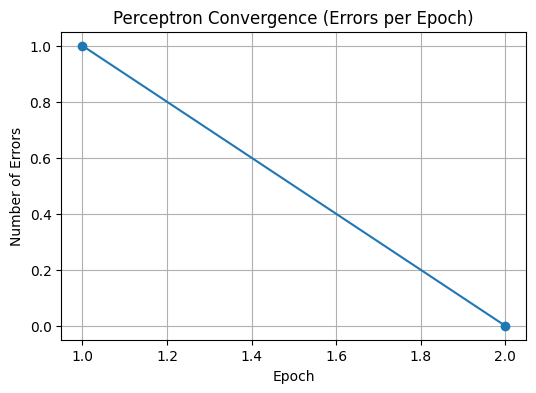

In [328]:
# Plot amount of mistakes per epoch
plt.figure(figsize=(6,4))
plt.plot(range(1, len(model.history)+1), model.history, marker='o')
plt.title("Perceptron Convergence (Errors per Epoch)")
plt.xlabel("Epoch")
plt.ylabel("Number of Errors")
plt.grid(True)
plt.show()

### Margin Explanation

Distance from the closest point to the decision boundary.

- For a linear classifier with weights \(w\) and bias \(b\):

$$
\text{distance from point } x_i \text{ to boundary } = \frac{|w \cdot x_i + b|}{\|w\|}
$$

- The Perceptron finds a separating line, but it does not maximize the margin.
- We visualize the classifier’s separation by drawing parallel lines through the closest positive and negative points. The actual geometric margin is the smallest signed distance to the boundary.

In [329]:
def compute_margin(model, X, y):
    scores = X @ model.weights + model.bias                             # raw scores
    norm_w = np.linalg.norm(model.weights)                              # length of the weight vector

    if norm_w == 0:
        raise ValueError("Margin undefined because weights are zero.")
    
    signed_margins = y * scores / norm_w                                # signed distance of each point from the boundary
    idx = np.argmin(signed_margins)                                     # smallest signed distance is the margin
    
    return signed_margins[idx], X[idx]                                  # return margin value and closest point

margin, closest_point = compute_margin(model, X, y)
print(f"Perceptron margin: {margin:.3f}")
print(f"Closest point to boundary: {closest_point}")

Perceptron margin: 0.946
Closest point to boundary: [-0.57870847 -1.30930874]


### Decision Boundary Plot

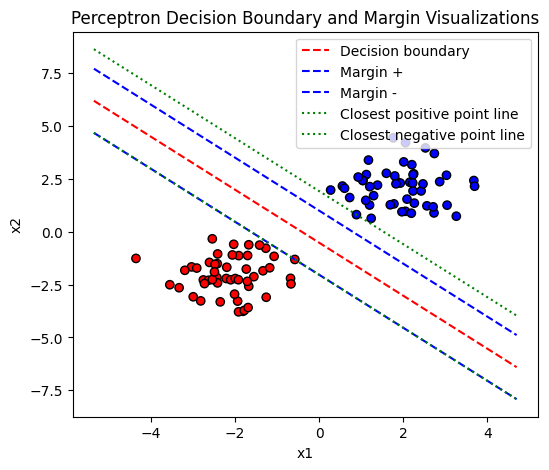

In [330]:
w = model.weights
b = model.bias

colors = ['red' if label == -1 else 'blue' for label in y]

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=colors, edgecolor='k')

slope = -w[0] / w[1]                                                        # compute slope of decision boundary
intercept = -b / w[1]                                                       # computer intercept of the decision boundary

x_vals = np.array([X[:,0].min() - 1, X[:,0].max() + 1])                     # define x-range for plotting lines
y_vals = slope * x_vals + intercept                                         # compute y values for the decision boundary
plt.plot(x_vals, y_vals, 'r--', label="Decision boundary")                  # draw the perceptron's decision boundary

offset = margin * np.linalg.norm(w)                                         # convert margin into line offset

y_margin_pos = -(w[0] * x_vals + b - offset) / w[1]                         # compute line for positive margin boundary
y_margin_neg = -(w[0] * x_vals + b + offset) / w[1]                         # compute line for negative margin boundary

plt.plot(x_vals, y_margin_pos, 'b--', label="Margin +")
plt.plot(x_vals, y_margin_neg, 'b--', label="Margin -")

distances = np.abs(X @ w + b) / np.linalg.norm(w)                           # compute perpendicular distances of all points to boundary
closest_pos = X[y == 1][np.argmin(distances[y == 1])]                       # find closest positive point to boundary
closest_neg = X[y == -1][np.argmin(distances[y == -1])]                     # find closest negative point to boundary

y_closest_pos = slope * x_vals + (closest_pos[1] - slope * closest_pos[0])  # line through closest positive point
y_closest_neg = slope * x_vals + (closest_neg[1] - slope * closest_neg[0])  # line through closest negative point

plt.plot(x_vals, y_closest_pos, 'g:', label="Closest positive point line")
plt.plot(x_vals, y_closest_neg, 'g:', label="Closest negative point line")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Perceptron Decision Boundary and Margin Visualizations")
plt.legend()
plt.show()


### Comparison with Sklearn

We train `sklearn.linear_model.Perceptron` on the same dataset and with similar settings.

Even if the learned weights are not exactly identical, both models should produce a very similar separating boundary and the same predictions on this linearly separable dataset.

In [331]:
sk_model = SklearnPerceptron(
    max_iter=10,
    tol=None,
    shuffle=True,
    penalty=None,
    random_state=42
)

sk_model.fit(X, y)

custom_preds = model.predict(X)
sklearn_preds = sk_model.predict(X)

custom_acc = accuracy_score(y, custom_preds)
sklearn_acc = accuracy_score(y, sklearn_preds)

print(f"Custom Perceptron accuracy:  {custom_acc:.3f}")
print(f"Sklearn Perceptron accuracy: {sklearn_acc:.3f}")
print()
print("Custom weights:", model.weights)
print("Custom bias:", model.bias)
print("Sklearn weights:", sk_model.coef_[0])
print("Sklearn bias:", sk_model.intercept_[0])

Custom Perceptron accuracy:  1.000
Sklearn Perceptron accuracy: 1.000

Custom weights: [2.42591386 1.93445398]
Custom bias: 1.0
Sklearn weights: [2.19268437 0.8788351 ]
Sklearn bias: 1.0


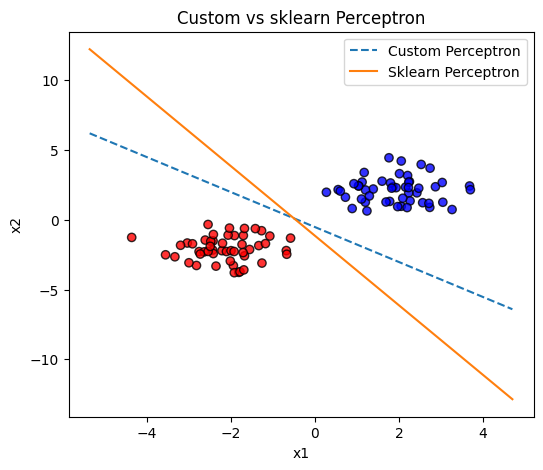

In [332]:
colors = ['red' if label == -1 else 'blue' for label in y]
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=colors, edgecolor='k', alpha=0.8)

x_vals = np.array([X[:, 0].min() - 1, X[:, 0].max() + 1])

w1, b1 = model.weights, model.bias
y_vals_1 = -(w1[0] * x_vals + b1) / w1[1]
plt.plot(x_vals, y_vals_1, '--', label='Custom Perceptron')

w2, b2 = sk_model.coef_[0], sk_model.intercept_[0]
y_vals_2 = -(w2[0] * x_vals + b2) / w2[1]
plt.plot(x_vals, y_vals_2, '-', label='Sklearn Perceptron')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Custom vs sklearn Perceptron')
plt.legend()
plt.show()

### Non-separable Case

Now we make the classes overlap more, which typically means that there is no perfect straight line that separates all points.

In that case, the Perceptron usually does not converge to zero mistakes. It keeps updating until it reaches the maximum number of iterations.

In [333]:
X_non, y_non_raw = make_blobs(
    n_samples=100,
    centers=[(-1, -1), (1, 1)],
    cluster_std=1.8,
    random_state=42
)

y_non = np.where(y_non_raw == 0, -1, 1)

model_non = Perceptron(n_features=X_non.shape[1], max_iter=50)
model_non.fit(X_non, y_non)

errors_non = model_non.history
y_non_pred = model_non.predict(X_non)
acc_non = accuracy_score(y_non, y_non_pred)

print('Weights:', model_non.weights)
print('Bias:', model_non.bias)
print('Epochs used:', len(errors_non))
print('Last 10 error counts:', errors_non[-10:])
print('Training accuracy:', acc_non)

Weights: [2.28854051 2.76944574]
Bias: 0.0
Epochs used: 50
Last 10 error counts: [27, 24, 26, 26, 24, 24, 22, 19, 21, 21]
Training accuracy: 0.78


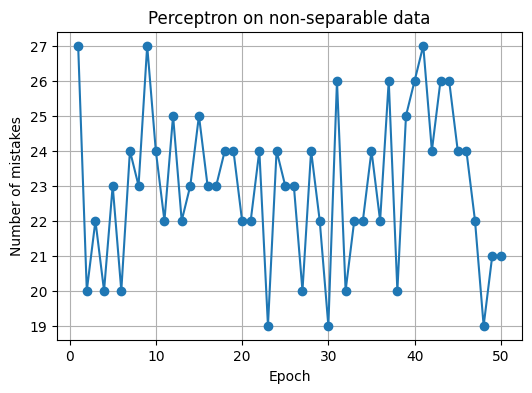

In [334]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(errors_non) + 1), errors_non, marker='o')
plt.title('Perceptron on non-separable data')
plt.xlabel('Epoch')
plt.ylabel('Number of mistakes')
plt.grid(True)
plt.show()

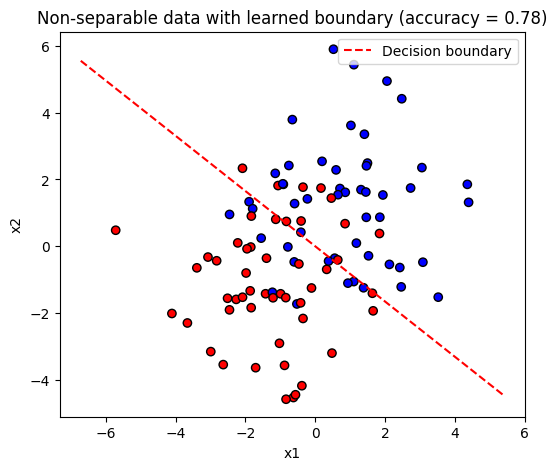

In [335]:
w_non = model_non.weights
b_non = model_non.bias

colors_non = ['red' if label == -1 else 'blue' for label in y_non]

plt.figure(figsize=(6,5))
plt.scatter(X_non[:,0], X_non[:,1], c=colors_non, edgecolor='k')

slope_non = -w_non[0] / w_non[1]
intercept_non = -b_non / w_non[1]

x_vals_non = np.array([X_non[:,0].min() - 1, X_non[:,0].max() + 1])
y_vals_non = slope_non * x_vals_non + intercept_non

plt.plot(x_vals_non, y_vals_non, 'r--', label='Decision boundary')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title(f'Non-separable data with learned boundary (accuracy = {acc_non:.2f})')
plt.legend()
plt.show()